## Sprint 10
### Nivel 1

##### Ejercicio 1
1. Importa como un DataFrame el archivo sprint10.xlsx. 
- Asegúrate de que el archivo se importa correctamente, con los nombres de columnas que le corresponden, sin manipular el archivo original.

2. Ordena el DataFrame por el país de origen. En caso de empate, ordena por el nombre de la ciudad.

3. Muestra las primeras 10 filas.

4. Adicionalmente, realiza un print donde compruebe que el DNI sólo tiene valores únicos.

ya tenia pandas instalado :)


In [ ]:
! pip show pandas

Name: pandas
Version: 2.3.0
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: https://pandas.pydata.org
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License

 Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
 All rights reserved.

 Copyright (c) 2011-2023, Open source contributors.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contribut

In [3]:
#para ver la direccion de mi entorno
#just in case
import os
os.getcwd()


'c:\\Users\\ADMIN\\Desktop\\Barcelona Activa\\Bootcamp\\Especializacion mentorizada\\Sprint 10'

Debido a que el archivo que hay q cargar es .xlsx tengo que instalar este paquete para leerlo


In [4]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [5]:
#ahora si a cargar el archivo:
import pandas as pd
df=pd.read_excel("sprint10.xlsx", header=3, index_col=0)
df.head(5)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
0,Inês,Ferreira Silva,16928694K,Portugal,Lisboa,25,2,1953,D,1.144 €,NaN,1.0,Grup B
1,Clara,Sánchez Martínez,27724652S,Espanya,Barcelona,18,3,1996,D,1.253 €,1.0,NaN,Grup A
2,Fatima,Fassi,38141675A,Marroc,Rabat,6,11,2005,A,1.441 €,1.0,NaN,Grup A
3,Khadija,Bennani Bennani,59157262R,Marroc,Rabat,20,1,1995,D,1.944 €,NaN,1.0,Grup B
4,Toni,Sánchez García,69630528M,Espanya,Barcelona,9,8,1999,H,1.043 €,NaN,1.0,Grup A


### limpieza del data frame:

- no me gustan los nombres de las columnas asi
    1. no manejo bien el catalan
    2. los nombres estan muy largos para manilacion de datos entonces los voy a cambiar

- como el cataln usa tildes para ambos lados y la ç y el sombrerito, voy a estandarizar los textos para evitar que una misma cosa se interprete de dos maneras (ejemplo: Sanchez y Sánchez) y para acceder mas facil a la informacion.

In [6]:
#renombrar columnas
nuevos_nom_columnas = {
    "Nom":"nombre",
    "Cognoms":"apellidos",
    "DNI":"dni",
    "País d'origen": "pais_origen",
    "Ciutat": "ciudad",
    "Dia de Naixement": "dia_nacimiento",
    "Mes de Naixement": "mes_nacimiento",
    "Any de Naixement": "anio_nacimiento",
    "Gènere": "genero",
    "Salari mensual": "salario_mensual",
    "Fills":"hijos",
    "No Fills":"no_hijos",
    "Grup Professional": "grupo_profesional"}

df.rename(columns=nuevos_nom_columnas, inplace=True)
df.tail(5)

#quitar acentos:
import unicodedata

def limpiar_texto(texto):
    if isinstance(texto, str):
        # Normaliza y quita tildes/acentos:
        texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
        return texto
    return texto

# lista de columnas a la que se lo aplicamos:
columnas_texto = ["nombre", "apellidos", "pais_origen", "ciudad"]

#limpieza de las columnas:
df[columnas_texto] = df[columnas_texto].map(limpiar_texto)

#verificacion:
print(df["apellidos"].unique())

df

['Ferreira Silva' 'Sanchez Martinez' 'Fassi' 'Bennani Bennani'
 'Sanchez Garcia' 'Castells Ferrer' 'Garcia' 'Rossi' 'Martinez' 'Sanchez'
 'Martinez Martinez' 'Dubois' 'Castells Romero' 'Castells' 'Romero'
 'Hernandez Ramirez' 'Garcia Lopez' 'Lopez' 'Castells Martinez'
 'Schneider Fischer' 'Martinez Sanchez' 'Oliveira Pereira' 'Lefevre'
 'Ferrer' 'Romero Martinez' 'Lopez Martinez' 'Rodriguez Fernandez'
 'Ferrer Romero' 'Lopez Ferrer' 'Martinez Castells' 'Gomez Alvarez'
 'Jones' 'Ferrer Martinez' 'Ferrer Ferrer' 'Lopez Sanchez' 'Conti'
 'Fernandez Alvarez' 'Gonzalez' 'Ramirez Hernandez' 'Sanchez Lopez'
 'Torres Torres' 'Schneider' 'Ferrer Lopez' 'Moreau' 'Ferrer Sanchez'
 'Gutierrez Castro' 'Castro Castro' 'Bennani' 'Taylor' 'Zahraoui'
 'Romero Romero' 'Ferreira' 'Brown' 'Torres' 'Martinez Ferrer'
 'Ferrer Castells' 'Jones Brown' 'Castells Castells' 'Castells Garcia'
 'Muller' 'Castells Sanchez' 'Silva Pereira' 'Garcia Ferrer'
 'Sanchez Castells' 'Castro' 'Girard' 'Romero Castells' 'Russ

,nombre,apellidos,dni,pais_origen,ciudad,dia_nacimiento,mes_nacimiento,anio_nacimiento,genero,salario_mensual,hijos,no_hijos,grupo_profesional
0,Ines,Ferreira Silva,16928694K,Portugal,Lisboa,25,2,1953,D,1.144 €,NaN,1.0,Grup B
1,Clara,Sanchez Martinez,27724652S,Espanya,Barcelona,18,3,1996,D,1.253 €,1.0,NaN,Grup A
2,Fatima,Fassi,38141675A,Marroc,Rabat,6,11,2005,A,1.441 €,1.0,NaN,Grup A
3,Khadija,Bennani Bennani,59157262R,Marroc,Rabat,20,1,1995,D,1.944 €,NaN,1.0,Grup B
4,Toni,Sanchez Garcia,69630528M,Espanya,Barcelona,9,8,1999,H,1.043 €,NaN,1.0,Grup A
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Marta,Ferrer Ferrer,25161375F,Espanya,Sevilla,1,6,1951,D,1.216 €,NaN,1.0,Grup B
996,Joan,Garcia,52145541P,Espanya,Sevilla,11,4,1959,H,971 €,NaN,1.0,Grup A
997,Laia,Ferrer Martinez,69760120X,Espanya,Barcelona,11,11,1980,D,682 €,NaN,1.0,Grup A
998,Jordi,Garcia,82947791W,Espanya,Barcelona,23,5,1984,H,1.699 €,1.0,NaN,Grup C


### Limpieza:

La columna "salario_mensual" tiene el simbolo de euros por lo que python la lee como texto:
 - quitar el simbolo
 - la columna debe ser un decimal e indicar que los montons van en miles (oojo con la ,/.)

In [7]:
df['salario_mensual'] = df['salario_mensual'].str.replace('€', '').str.replace('.', '').str.strip().astype(float)
#al correr el codigo por segunda vez sale el error porque al volverlo a correr 
# evidentemente ya no encuentra ni simbolos ni espacios.

#verificacion del anterior
df

,nombre,apellidos,dni,pais_origen,ciudad,dia_nacimiento,mes_nacimiento,anio_nacimiento,genero,salario_mensual,hijos,no_hijos,grupo_profesional
0,Ines,Ferreira Silva,16928694K,Portugal,Lisboa,25,2,1953,D,1144.0,NaN,1.0,Grup B
1,Clara,Sanchez Martinez,27724652S,Espanya,Barcelona,18,3,1996,D,1253.0,1.0,NaN,Grup A
2,Fatima,Fassi,38141675A,Marroc,Rabat,6,11,2005,A,1441.0,1.0,NaN,Grup A
3,Khadija,Bennani Bennani,59157262R,Marroc,Rabat,20,1,1995,D,1944.0,NaN,1.0,Grup B
4,Toni,Sanchez Garcia,69630528M,Espanya,Barcelona,9,8,1999,H,1043.0,NaN,1.0,Grup A
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Marta,Ferrer Ferrer,25161375F,Espanya,Sevilla,1,6,1951,D,1216.0,NaN,1.0,Grup B
996,Joan,Garcia,52145541P,Espanya,Sevilla,11,4,1959,H,971.0,NaN,1.0,Grup A
997,Laia,Ferrer Martinez,69760120X,Espanya,Barcelona,11,11,1980,D,682.0,NaN,1.0,Grup A
998,Jordi,Garcia,82947791W,Espanya,Barcelona,23,5,1984,H,1699.0,1.0,NaN,Grup C


### Limpiar hijos y no_hijos

son dos columnas con la misma info, por lo que pretendo es unificarlas en una sola columna con valores booleanos
entonces
los NaN se convierten en ceros
y los verdaderos en 1 (que ya lo hizo python automaticamente)

donde 
1=True
0=False por tanto [tiene_hijos].astype tiene que ser si o si bool


In [8]:
# 1.crear la nueva columna:
df["tiene_hijos"] = df["hijos"].fillna(0).astype(bool)

# 2. eliminar columnas repetidas:
df.drop(columns=["hijos", "no_hijos"], inplace=True)

# 3. Verificacion:
print(df[['nombre', 'apellidos', 'tiene_hijos']].head())

df

    nombre         apellidos  tiene_hijos
0     Ines    Ferreira Silva        False
1    Clara  Sanchez Martinez         True
2   Fatima             Fassi         True
3  Khadija   Bennani Bennani        False
4     Toni    Sanchez Garcia        False


,nombre,apellidos,dni,pais_origen,ciudad,dia_nacimiento,mes_nacimiento,anio_nacimiento,genero,salario_mensual,grupo_profesional,tiene_hijos
0,Ines,Ferreira Silva,16928694K,Portugal,Lisboa,25,2,1953,D,1144.0,Grup B,False
1,Clara,Sanchez Martinez,27724652S,Espanya,Barcelona,18,3,1996,D,1253.0,Grup A,True
2,Fatima,Fassi,38141675A,Marroc,Rabat,6,11,2005,A,1441.0,Grup A,True
3,Khadija,Bennani Bennani,59157262R,Marroc,Rabat,20,1,1995,D,1944.0,Grup B,False
4,Toni,Sanchez Garcia,69630528M,Espanya,Barcelona,9,8,1999,H,1043.0,Grup A,False
...,...,...,...,...,...,...,...,...,...,...,...,...
995,Marta,Ferrer Ferrer,25161375F,Espanya,Sevilla,1,6,1951,D,1216.0,Grup B,False
996,Joan,Garcia,52145541P,Espanya,Sevilla,11,4,1959,H,971.0,Grup A,False
997,Laia,Ferrer Martinez,69760120X,Espanya,Barcelona,11,11,1980,D,682.0,Grup A,False
998,Jordi,Garcia,82947791W,Espanya,Barcelona,23,5,1984,H,1699.0,Grup C,True


## Sprint 10
### Nivel 1

##### Ejercicio 1
1. Importa como un DataFrame el archivo sprint10.xlsx. Asegúrate de que el archivo se importa correctamente, con los nombres de columnas que le corresponden, sin manipular el archivo original. (CHECK)

2. Ordena el DataFrame por el país de origen. En caso de empate, ordena por el nombre de la ciudad.

3. Muestra las primeras 10 filas.

In [9]:
#2. ordenar por pais_origen y ciudad(para desempate)
df_ordenado=df.sort_values(["pais_origen", "ciudad"], ascending=True)

#3.
df_ordenado.head(10)

,nombre,apellidos,dni,pais_origen,ciudad,dia_nacimiento,mes_nacimiento,anio_nacimiento,genero,salario_mensual,grupo_profesional,tiene_hijos
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlin,22,10,1976,A,951.0,Grup A,False
154,Laura,Schneider Fischer,37399141L,Alemanya,Berlin,2,2,1958,D,1769.0,Grup B,True
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlin,23,10,2005,D,2013.0,Grup B,False
278,Mia,Fischer,21390098Z,Alemanya,Berlin,11,8,1950,D,1557.0,Grup B,True
602,Jonas,Schneider,44060014R,Alemanya,Berlin,22,11,1985,H,2754.0,Grup D,True
871,Lea,Fischer,14773153R,Alemanya,Berlin,9,9,1986,D,1370.0,Grup A,True
281,Lea,Muller,23266650S,Alemanya,Hamburg,14,4,2003,D,1314.0,Grup A,False
435,Anna,Muller,83274277X,Alemanya,Hamburg,1,1,1987,D,2464.0,Grup C,False
444,Laura,Schmidt Muller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2035.0,Grup C,True
487,Lukas,Muller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2042.0,Grup B,False


## Sprint 10
### Nivel 1

##### Ejercicio 1
Realiza un print donde compruebe que el DNI sólo tiene valores únicos.

In [10]:
dni_unicos=df["dni"].is_unique

if dni_unicos:
    print("Todos los DNI's son unicos.")
else:
    total_duplicados=df["dni"].duplicated().sum()
    print(f"Hay {total_duplicados} DNI's duplicados.")
    

Todos los DNI's son unicos.


## Sprint 10
### Nivel 1

##### Ejercicio 2
1. Crea una columna que sea el nombre completo.

2. Crea una columna si la persona ha nacido en España o no.

3. Pone el DNI como índice del DataFrame (nombres de filas).

4. Sustituye el nombre de las columnas Día de Nacimiento, Mes de Nacimiento y Año de Nacimiento por Día, Mes y Año.

5. Sustituye a H por Hombre, D por Mujer, A por Otros y NC por un dato faltante (enano/null/na).

6. Muestra todos los cambios que has realizado en una sola tabla.

In [11]:
#1. Añadir columna "nombre_completo"
df.insert(2,"nombre_completo", df["nombre"]+" "+ df["apellidos"])

#2. Columna de nacionalidad española
df.insert(5,"nacido_espanya", df["pais_origen"]=="Espanya")

#3. convertir la columna dni como índice de la tabla
df.set_index('dni', inplace=True)

#4. Cambio de nombre de columnas:
df.rename(columns={
    "dia_nacimiento": "dia",
    "mes_nacimiento": "mes",
    "anio_nacimiento": "año"}, inplace=True)

#5. H por hombre
#   D por mujer
#   A por otros
#   NC por null

#diccionario directamente en la columna + replace
df["genero"] = df["genero"].replace({
    "H": "Hombre",
    "D": "Mujer",
    "A": "Otros",
    "NC": "null"})

#6. Mostrar tabla:
df.head(15)

,nombre,apellidos,nombre_completo,pais_origen,nacido_espanya,ciudad,dia,mes,año,genero,salario_mensual,grupo_profesional,tiene_hijos
dni,,,,,,,,,,,,,
16928694K,Ines,Ferreira Silva,Ines Ferreira Silva,Portugal,False,Lisboa,25,2,1953,Mujer,1144.0,Grup B,False
27724652S,Clara,Sanchez Martinez,Clara Sanchez Martinez,Espanya,True,Barcelona,18,3,1996,Mujer,1253.0,Grup A,True
38141675A,Fatima,Fassi,Fatima Fassi,Marroc,False,Rabat,6,11,2005,Otros,1441.0,Grup A,True
59157262R,Khadija,Bennani Bennani,Khadija Bennani Bennani,Marroc,False,Rabat,20,1,1995,Mujer,1944.0,Grup B,False
69630528M,Toni,Sanchez Garcia,Toni Sanchez Garcia,Espanya,True,Barcelona,9,8,1999,Hombre,1043.0,Grup A,False
26930927E,Laia,Castells Ferrer,Laia Castells Ferrer,Espanya,True,Madrid,16,12,1953,Otros,2611.0,Grup D,False
78247593G,Carla,Garcia,Carla Garcia,Espanya,True,Valencia,24,12,1957,Mujer,942.0,Grup A,False
21774231J,Marco,Rossi,Marco Rossi,Italia,False,Tori,3,11,2002,Otros,1494.0,Grup A,False
87316866D,Alessia,Rossi,Alessia Rossi,Italia,False,Mila,6,12,1989,Mujer,1366.0,Grup A,False


## Sprint 10
### Nivel 1

##### Ejercicio 3
Junta las columnas Hijos y No Hijos en una sola columna, utilizando el método .apply() y definiendo una función que resuelva el problema. La columna nueva debe llamarse "Hijos" y tomar los valores "Sí" o "No".


Debido a que la unificacion de las columnas lo habia hecho con anterioridad voy a hacer el reemplazo de true y false por si y no pero esta vez usando el metodo.apply, como pide el ejercicio.

In [12]:
def transformar_hijos(boolean):
    if boolean == True:
        return "SI"
    else:
        return "NO"

#entonces:
df["hijos"] = df["tiene_hijos"].apply(transformar_hijos)

#se elimina la anterir columna
df.drop(columns=["tiene_hijos"], inplace=True)

#verificacion
df

,nombre,apellidos,nombre_completo,pais_origen,nacido_espanya,ciudad,dia,mes,año,genero,salario_mensual,grupo_profesional,hijos
dni,,,,,,,,,,,,,
16928694K,Ines,Ferreira Silva,Ines Ferreira Silva,Portugal,False,Lisboa,25,2,1953,Mujer,1144.0,Grup B,NO
27724652S,Clara,Sanchez Martinez,Clara Sanchez Martinez,Espanya,True,Barcelona,18,3,1996,Mujer,1253.0,Grup A,SI
38141675A,Fatima,Fassi,Fatima Fassi,Marroc,False,Rabat,6,11,2005,Otros,1441.0,Grup A,SI
59157262R,Khadija,Bennani Bennani,Khadija Bennani Bennani,Marroc,False,Rabat,20,1,1995,Mujer,1944.0,Grup B,NO
69630528M,Toni,Sanchez Garcia,Toni Sanchez Garcia,Espanya,True,Barcelona,9,8,1999,Hombre,1043.0,Grup A,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25161375F,Marta,Ferrer Ferrer,Marta Ferrer Ferrer,Espanya,True,Sevilla,1,6,1951,Mujer,1216.0,Grup B,NO
52145541P,Joan,Garcia,Joan Garcia,Espanya,True,Sevilla,11,4,1959,Hombre,971.0,Grup A,NO
69760120X,Laia,Ferrer Martinez,Laia Ferrer Martinez,Espanya,True,Barcelona,11,11,1980,Mujer,682.0,Grup A,NO


## Sprint 10
### Nivel 1

##### Ejercicio 4
Crea una tabla resumen que permita ver el sueldo medio, mínimo y máximo por Género.

y Ordena la tabla en función del sueldo medio

In [13]:
sueldo_genero=df.groupby("genero")[["salario_mensual"]].agg({"salario_mensual":["mean","max","min"]}).round(2)

sueldo_genero.sort_values(by=("salario_mensual","mean"), ascending=False)


salario_mensual               
                  mean     max    min
genero                               
Hombre         1643.25  3356.0  737.0
Otros          1626.59  3175.0  703.0
null           1568.87  2969.0  758.0
Mujer          1469.44  3021.0  665.0

## Sprint 10
### Nivel 1

##### Ejercicio 5
Crea una tabla resumen con el salario medio por género (filas) y país de origen (columnas).

- Añade las medias a los márgenes de la tabla.

- (EXTRA): Aplica formato condicional en la tabla para ver en un color más intenso los valores más elevados

In [14]:
tabla_resumen=pd.crosstab(df["genero"],df["pais_origen"], 
            df["salario_mensual"], aggfunc="mean", 
            margins=True,margins_name="media_total").round(2)
tabla_resumen

pais_origen,Alemanya,Argentina,Colombia,Espanya,Franca,Italia,Marroc,Mexic,Portugal,Regne Unit,media_total
genero,,,,,,,,,,,
Hombre,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
Mujer,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Otros,951.00,1141.00,1030.00,1706.18,NaN,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
null,1931.50,1135.67,1252.00,1597.14,1573.00,1316.00,1365.50,1583.00,1553.50,1758.00,1568.87
media_total,1858.35,1431.68,1489.13,1582.16,1465.36,1421.17,1441.69,1559.08,1527.23,1448.33,1561.46


## Sprint 10
### Nivel 1

##### Ejercicio 5
Extra: Mapa de calor

colores mas fuertes=salarios mas elevados



In [15]:
%pip install jinja2

Note: you may need to restart the kernel to use updated packages.


In [16]:
tabla_resumen.style.background_gradient(cmap="Greens").format("{:.2f}")

pais_origen,Alemanya,Argentina,Colombia,Espanya,Franca,Italia,Marroc,Mexic,Portugal,Regne Unit,media_total
genero,,,,,,,,,,,
Hombre,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
Mujer,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Otros,951.00,1141.00,1030.00,1706.18,nan,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
null,1931.50,1135.67,1252.00,1597.14,1573.00,1316.00,1365.50,1583.00,1553.50,1758.00,1568.87
media_total,1858.35,1431.68,1489.13,1582.16,1465.36,1421.17,1441.69,1559.08,1527.23,1448.33,1561.46


## Sprint 10
### Nivel 1

##### Ejercicio 6
Crea una nueva columna que sea la fecha de nacimiento en formato Datetime a partir de las columnas día, mes y año. Utilizando esta columna crea una función que dada una fecha, te calcule la edad actual a día de hoy.

Utiliza la función que acabas de crear para generar una columna nueva en DataFrame con la edad actual.

In [17]:
#funcion to_datatime para crear la nueva columna:
df["fecha_nacimiento"]=pd.to_datetime(df[["dia","mes","año"]].rename(columns={"dia":"day",
                                                                              "mes":"month",
                                                                              "año":"year"}))

#funcion para calcular la edad actual hoy:
from datetime import datetime
def calcular_edad(fecha):
    hoy=datetime.now()
    edad=hoy.year-fecha.year-((hoy.month,hoy.day)<(fecha.month,fecha.day))
    return edad

#columna edad_actual
df["edad_actual"]=df["fecha_nacimiento"].apply(calcular_edad)

#verificacion:
df[["nombre_completo", "fecha_nacimiento", "edad_actual"]].head()


,nombre_completo,fecha_nacimiento,edad_actual
dni,,,
16928694K,Ines Ferreira Silva,1953-02-25,72
27724652S,Clara Sanchez Martinez,1996-03-18,29
38141675A,Fatima Fassi,2005-11-06,20
59157262R,Khadija Bennani Bennani,1995-01-20,30
69630528M,Toni Sanchez Garcia,1999-08-09,26


## Sprint 10
### Nivel 2

##### Ejercicio 1

- Utilizando el siguiente DataFrame, adjunta la columna "Incremento" al dataframe del nivel anterior.

In [18]:
#df_incremento:
df_incremento = pd.DataFrame({"Grupo":["Grup A","Grup B","Grup C", "Grup D" ],
                             "Incremento": ["5%","3,5%","2%","8%"]})
#Nota: en el df base, la columna de grupo_profesional pone "grup" en lugar de "grupo".
#por lo que al crear el df_incremento lo cree igual para no tener que cambiarlo en el df base por mucho toc que me da.
df_incremento

#verificacion de que ambos df tengan los mismos grupos 

grupos_unicos_A=sorted(df["grupo_profesional"].unique())
grupos_unicos_B=sorted(df_incremento["Grupo"].unique())

dummie_data={"df_A":grupos_unicos_A,
             "df_B": grupos_unicos_B}
d_d=pd.DataFrame(dummie_data,columns=["df_A","df_B"])
d_d


#grupo_profesional de df tiene que coincidir con el grupo de df_incremento:
#columna clave grupo_profesional-->Grupo
df=df.merge(df_incremento,left_on="grupo_profesional", right_on="Grupo", how="left")
df.drop(columns=["Grupo"], inplace=True)

df



,nombre,apellidos,nombre_completo,pais_origen,nacido_espanya,ciudad,dia,mes,año,genero,salario_mensual,grupo_profesional,hijos,fecha_nacimiento,edad_actual,Incremento
0,Ines,Ferreira Silva,Ines Ferreira Silva,Portugal,False,Lisboa,25,2,1953,Mujer,1144.0,Grup B,NO,1953-02-25,72,"3,5%"
1,Clara,Sanchez Martinez,Clara Sanchez Martinez,Espanya,True,Barcelona,18,3,1996,Mujer,1253.0,Grup A,SI,1996-03-18,29,5%
2,Fatima,Fassi,Fatima Fassi,Marroc,False,Rabat,6,11,2005,Otros,1441.0,Grup A,SI,2005-11-06,20,5%
3,Khadija,Bennani Bennani,Khadija Bennani Bennani,Marroc,False,Rabat,20,1,1995,Mujer,1944.0,Grup B,NO,1995-01-20,30,"3,5%"
4,Toni,Sanchez Garcia,Toni Sanchez Garcia,Espanya,True,Barcelona,9,8,1999,Hombre,1043.0,Grup A,NO,1999-08-09,26,5%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Marta,Ferrer Ferrer,Marta Ferrer Ferrer,Espanya,True,Sevilla,1,6,1951,Mujer,1216.0,Grup B,NO,1951-06-01,74,"3,5%"
996,Joan,Garcia,Joan Garcia,Espanya,True,Sevilla,11,4,1959,Hombre,971.0,Grup A,NO,1959-04-11,66,5%
997,Laia,Ferrer Martinez,Laia Ferrer Martinez,Espanya,True,Barcelona,11,11,1980,Mujer,682.0,Grup A,NO,1980-11-11,45,5%
998,Jordi,Garcia,Jordi Garcia,Espanya,True,Barcelona,23,5,1984,Hombre,1699.0,Grup C,SI,1984-05-23,41,2%


## Sprint 10
### Nivel 2

##### Ejercicio 1

- Actualiza la columna salario en función de los porcentajes que se adjuntan. No modifiques manualmente los incrementos, escribe código Python para realizar las conversiones necesarias.

In [19]:
#de % a decimal:
df["Incremento_decimal"] = df["Incremento"].str.replace("%", " ").str.replace(",", "." ).astype(float) / 100

#operacion: salario_mesual*(1+incremento_decimal):

df["salario_incrementado"]=(df["salario_mensual"]*(1+ df["Incremento_decimal"])).round(2)

#verificacion:
df[["nombre_completo", "salario_mensual", "salario_incrementado","Incremento", "Incremento_decimal"]].head(25)

,nombre_completo,salario_mensual,salario_incrementado,Incremento,Incremento_decimal
0,Ines Ferreira Silva,1144.0,1184.04,"3,5%",0.035
1,Clara Sanchez Martinez,1253.0,1315.65,5%,0.050
2,Fatima Fassi,1441.0,1513.05,5%,0.050
3,Khadija Bennani Bennani,1944.0,2012.04,"3,5%",0.035
4,Toni Sanchez Garcia,1043.0,1095.15,5%,0.050
5,Laia Castells Ferrer,2611.0,2819.88,8%,0.080
6,Carla Garcia,942.0,989.10,5%,0.050
7,Marco Rossi,1494.0,1568.70,5%,0.050
8,Alessia Rossi,1366.0,1434.30,5%,0.050
9,Toni Martinez,891.0,935.55,5%,0.050


## Sprint 10
### Nivel 2

##### Ejercicio 2

- Utilizando un bucle, exporta en 4 archivos (formato .xlsx o .csv) los datos de cada Grupo Profesional.

Por ejemplo: "datos_GrupA.xlsx" , "datos_GrupB.xlsx" ...

In [20]:
#agrupacion por grupo_profesional
grupos = df.groupby("grupo_profesional")

#bucle for para 1.nombre de cada grupo y 2. df de cada grupo 

for nombre_grupo, datos in grupos:
    # Limpiamos el nombre para que no tenga espacios al nombrar el archivo
    nombre_archivo = nombre_grupo.replace(" ", "")
    
    datos.to_excel(f"datos_{nombre_archivo}.xlsx", index=False)
    
    print(f"Archivo exportado: datos_{nombre_archivo}.xlsx")

Archivo exportado: datos_GrupA.xlsx
Archivo exportado: datos_GrupB.xlsx
Archivo exportado: datos_GrupC.xlsx
Archivo exportado: datos_GrupD.xlsx


In [21]:
#recordemos que:
os.getcwd()

'c:\\Users\\ADMIN\\Desktop\\Barcelona Activa\\Bootcamp\\Especializacion mentorizada\\Sprint 10'

## Sprint 10
### Nivel 2

##### Ejercicio 2
- Exporta un 5º DataFrame en formato .xlsx o .csv que contenga cuántos trabajadores hay por cada Grupo Profesional, cuál es su sueldo medio y cuál es su edad media.

In [22]:
df_5 = df.groupby("grupo_profesional").agg({"nombre_completo": "count",
                                            "salario_incrementado": "mean",
                                            "edad_actual": "mean"})

df_5.columns = ["Numero de trabajadores", "Sueldo Medio", "Edad Media"]
df_5 = df_5.round(2)
df_5

df_5.to_excel("resumen_grupos.xlsx")
os.getcwd()

'c:\\Users\\ADMIN\\Desktop\\Barcelona Activa\\Bootcamp\\Especializacion mentorizada\\Sprint 10'

## Sprint 10
### Nivel 3

##### Ejercicio 1
Crea una función que tome un dataframe como parámetro de entrada.

La función debe crear (y exportar) un gráfico automáticamente para cada columna del dataframe. Por ejemplo:

un histograma/boxplot si la variable es numérica
unas barras de los valores más frecuentes si es categórica
unas barras de los años más frecuentes si el dato está en formato fecha.


In [23]:
%pip install seaborn
%pip install matplotlib
%pip install numpy

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

%pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


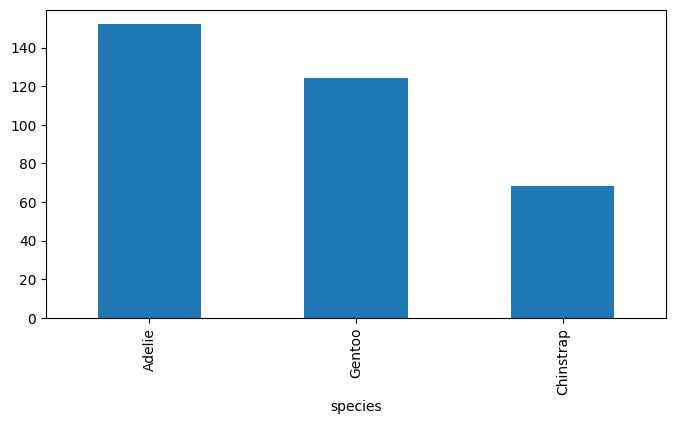

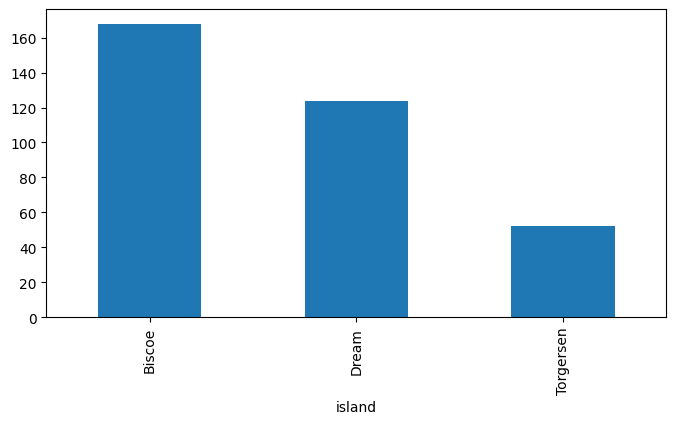

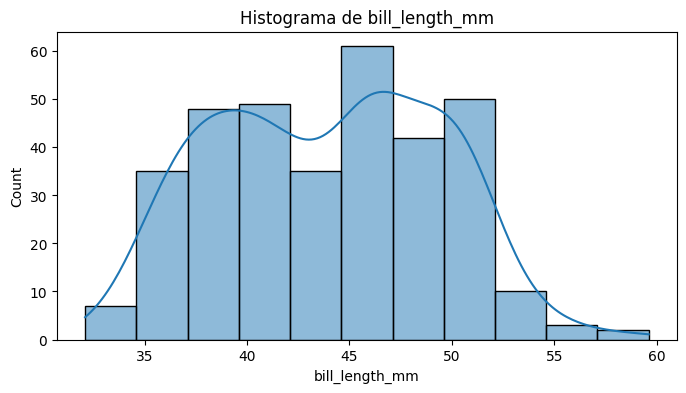

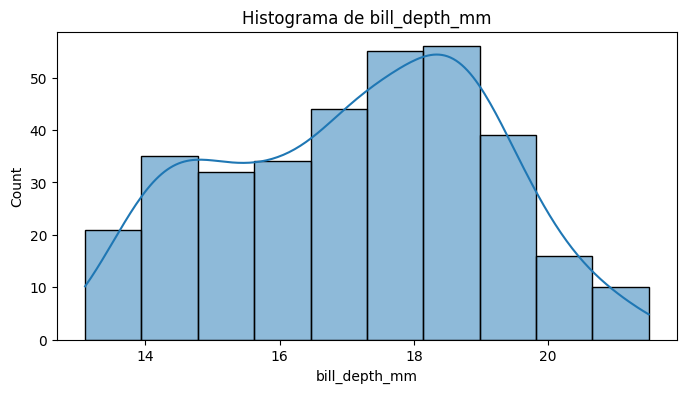

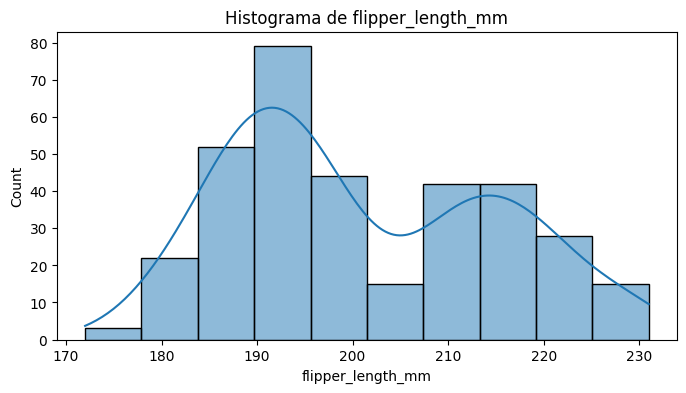

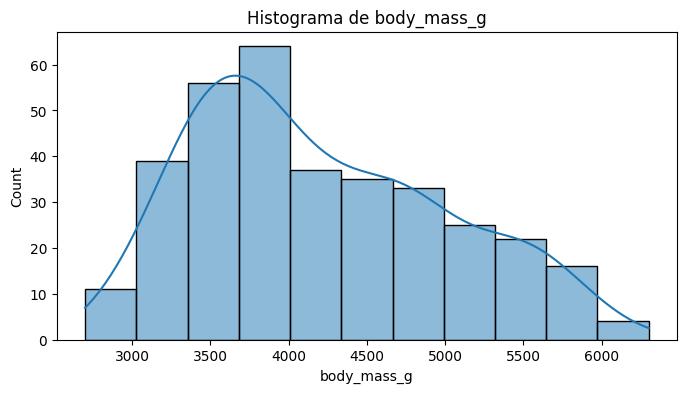

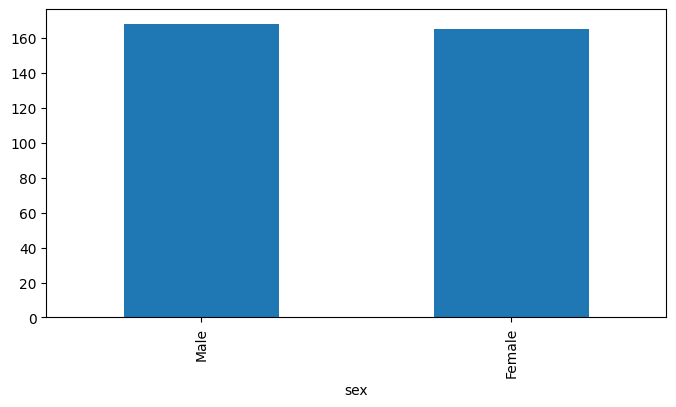

In [24]:
def funcion(dataframe): #funcion con un df como parametro
    for columna in dataframe.columns:    #bucle for que recorre cada columna del df
        plt.figure(figsize=(8,4))   #biblioteca y mesures de cada uno de los graficos(por separado)

#entonces, los condicionales:

#Si la variables es numerica -> histograma/
        if dataframe[columna].dtype == "int64" or dataframe[columna].dtype == "float64":
            sns.histplot(dataframe[columna], kde=True)
            plt.title(f"Histograma de {columna}")
#pero si la variable de la columna es categorica -> barras de frecuencias:
        elif dataframe[columna].dtype == 'object' or dataframe[columna].dtype == 'category':
            dataframe[columna].value_counts().head(10).plot(kind='bar')
#si la columna esta en formato fecha -> barra de frecuencias:
        elif 'datetime' in str(dataframe[columna].dtype):
            dataframe[columna].dt.year.value_counts().sort_index().plot(kind='bar')
        else:
            print(f"La columna {columna} tiene otro tipo de variables.")

#probando probando
dataframe = sns.load_dataset("penguins")
funcion(dataframe)

#paraa exportarlos:
plt.savefig(f"grafico_{"specie"}.png")

In [25]:
df_pingu=sns.load_dataset("penguins")
df_pingu

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## Sprint 10
### Nivel 3

##### Ejercicio 2

Preparacion de datos:
- Carga el archivo matriz_distancies.xlsx en pandas
- nombres de filas y de columnas sean los de las ciudades. 
- Borra "Las Palmas de Gran Canaria" y "Palma" 


In [26]:
df_distancias=pd.read_excel("matriu_distancies.xlsx", index_col=0)

del df_distancias["Las Palmas de Gran Canaria"], df_distancias["Palma"]
df_distancias=df_distancias.drop(index=["Las Palmas de Gran Canaria", "Palma"])

df_distancias


,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,NaN,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,NaN,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,583.0,NaN,379.0,515.0,821.0,722.0,401.0
Córdoba,711.0,421.0,121.0,535.0,133.0,320.0,618.0,379.0,NaN,419.0,589.0,634.0,704.0
Valladolid,576.0,441.0,486.0,320.0,549.0,510.0,232.0,515.0,419.0,NaN,337.0,224.0,570.0


## Sprint 10
### Nivel 3

##### Ejercicio 2

visitar todas las principales ciudades de España recorriendo la mínima distancia posible.

Haz una función que dada la matriz de distancias y la ciudad de origen, haga una propuesta de ruta que sea lo más corta posible que puedas, devolviendo una lista con el orden de visita. Da también la distancia total recorrida.

In [30]:
def calcular_ruta(df_distancias, ciudad_origen):
    ciudades_pendientes = list(df_distancias.columns)
    ciudades_pendientes.remove(ciudad_origen)
    
    ruta = [ciudad_origen]
    distancia_total = 0
    ciudad_actual = ciudad_origen    
    while ciudades_pendientes:
        # buscar ciudades faltantes desde ciudad_actual
        dist_desde_actual = df_distancias.loc[ciudad_actual, ciudades_pendientes]
        
        # ciudad más cercana
        proxima_ciudad = dist_desde_actual.idxmin()
        distancia_a_proxima = dist_desde_actual.min()
        
        distancia_total += distancia_a_proxima
        ruta.append(proxima_ciudad)
        ciudades_pendientes.remove(proxima_ciudad)
        ciudad_actual = proxima_ciudad
        
    return ruta, distancia_total

ruta_final, kms = calcular_ruta(df_distancias, input("Insertar la ciudad de origen"))
print(f"Ruta desde el origen: {' -> '.join(ruta_final)}")
print(f"Distancia total: {kms} km")

Ruta desde el origen: Valencia -> Alicante -> Murcia -> Córdoba -> Sevilla -> Málaga -> Valladolid -> Gijón -> Bilbao -> Zaragoza -> Hospitalet de Llobregat -> Barcelona -> Vigo
Distancia total: 3200.0 km
